# E48 - The Quantum-Effect Probe: quantum vs tempo, told apart (H435-H440)

**Author**: kj · **Round**: E48 · **Campaign**: demographic-collapse

A policymaker facing a projected fertility recovery needs the one thing the period TFR cannot tell them:
is this a durable gain in completed family size (**quantum**), or a timing mirage that borrows births
from the future and reverts (**tempo**, the Bongaarts-Feeney effect)? Near-term quantum recovery is real;
a tempo bump is illusory. This round builds a standalone diagnostic that returns that verdict automatically
for any intervention, reading the model's own B-F composition.

**What this round is, and is not.** The probe is a DIAGNOSTIC INSTRUMENT that operationalizes the model's
own Bongaarts-Feeney quantum-vs-tempo split. It reads the same decomposition from which the campaign's
dynamical verdicts were derived, so where the probe agrees with those verdicts it **reproduces the model's
own classifications by construction** - that agreement is an internal-consistency check, not an independent
validation of the campaign and not a discovered safety property. The parts that CAN fail, and therefore
carry the round, are narrow and specific: does a two-axis rule catch an error a one-axis rule makes (H436),
and is the classification robust to the one calibrated tempo constant (H440). Every bar below is written so
it can return non-SUPPORTED.

**The identity the model already composes** (Bongaarts & Feeney 1998/2006):

$$\text{TFR} = \underbrace{C(1-\rho)\bar P}_{\text{quantum}}\cdot\underbrace{\Psi_{\text{fec}}(\tau)}_{\text{fec}}\cdot\underbrace{\max(1-k_{BF}\,\dot\tau,\,0)}_{\text{tempo factor}},\qquad \text{adjTFR}^{*}=\text{quantum}\cdot\Psi_{\text{fec}}=\frac{\text{TFR}}{1-r_p}$$

A change in $\text{adjTFR}^{*}$ is a real change in completed family size; whatever the tempo factor carries
is borrowed timing that reverts when the mean-age shift stops. The probe turns this identity into a
two-axis classifier - **composition** (how much of $d\text{TFR}$ is the tempo factor, at peak effect) and
**durability** (does the adjusted-TFR\* gain survive to 2125).

**The bars (pre-registered, `reports/quantum_probe_fanout.md`)**: H435 reproduces the coarse labels
(agreement $\geq 0.90$) AND meaningfully beats a fair one-axis persistence-only comparator in aggregate -
falsifiable because a two-axis rule that only matches construction need not beat one-axis; H436 the
composition axis fixes a real one-axis error on the tempo push in $\geq 7/8$ regions; H437 the durability
split is real (eroding cash reverts, durable cash persists in $\geq 7/8$); H438 the full-catalogue screen
disagreement rate stays below a pre-set threshold with no coupling-escape read as TEMPO; H439 the
variation-capable levers (those that touch the tempo channel) are portable; H440 zero class flips under
$k_{BF}\in\{0.6, 1.0\}$.

**Discipline**: notebook-local diagnostic; NO `src/` edit; the harness is additive and baseline-preserving
(asserted bit-for-bit). **Output**: verdicts -> `reports/nb46_e48_verdicts.json`, figures ->
`reports/figures/nb46_*.png`.

## Imports

In [1]:
%load_ext autoreload
%autoreload 2

import os
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "GPU-58ae1f45-295c-681b-60ad-843265f52997")
import sys
sys.path.insert(0, "../src")

import csv
import json
import re
from collections import Counter
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
from rich import print as rprint
from rich.table import Table
from rich.console import Console

from sci_demographic_collapse.emergent import EmergentModel
from sci_demographic_collapse.emergent import C0, PARAMS

console = Console()

2026-07-11 22:52:16.337 | INFO     | sci_demographic_collapse.config:<module>:40 - PROJ_ROOT path is: /home/lab/workspace/learning/projects/sci-demographic-collapse


## Reproducibility

In [2]:
SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)

## Configuration

The eight calibrated regions, the three dynamical anchors E19 scored on (Korea collapse, Germany
intact-low, France stable), the four pre-registered probe thresholds, and the two-value `kBF` grid
(the E40 damped 0.6 and the E41-adjudicated undamped 1.0).

In [3]:
REGIONS = ["USA", "France", "Germany", "Italy", "Japan", "Korea", "Poland", "Israel"]
REGS3 = ["Korea", "Germany", "France"]          # the E19 dynamical anchors

# pre-registered probe thresholds (fixed BEFORE scoring; not tuned to the outcome)
TEMPO_HI, TEMPO_LO = 0.60, 0.40                 # tempo_share bands
PERS_HI, PERS_LO = 0.60, 0.40                   # persistence bands
KBF_GRID = [0.6, 1.0]                           # E40 damped / E41-adjudicated undamped

REPORTS = Path("../reports")
FIGS = Path("../reports/figures")
FIGS.mkdir(parents=True, exist_ok=True)

rprint(f"[cyan]regions[/cyan] {len(REGIONS)} · anchors {REGS3} · thresholds "
       f"tempo[{TEMPO_LO},{TEMPO_HI}] pers[{PERS_LO},{PERS_HI}] · kBF grid {KBF_GRID}")

regions 8 · anchors ['Korea', 'Germany', 'France'] · thresholds tempo[0.4,0.6] pers[0.4,0.6] · kBF grid [0.6, 1.0]

## The model and baseline preservation

Instantiate the shipped calibrated model. The E41 observability harness (`trajectories=True`) only
*collects* per-year series; it never feeds back into the dynamics, so the baseline must be identical
with the harness off vs on. We assert it bit-for-bit before trusting any decomposition, and confirm the
B-F decomposition keys are present.

In [4]:
m = EmergentModel(data_dir="../data/raw/unwpp")

# baseline-preservation guard: harness OFF vs ON, bit-for-bit, on all 8 regions
_off = {r: m.run_cal(r) for r in REGIONS}
_on = {r: m.run_cal(r, trajectories=True) for r in REGIONS}
assert all(_off[r]["tfr"] == _on[r]["tfr"] for r in REGIONS), "harness changed the baseline"
assert all((_off[r]["TFR"] == _on[r]["TFR"]).all() for r in REGIONS), "harness changed the trajectory"
BASE = _on  # cache the trajectory baselines
_k = BASE["Korea"]["trajectories"]
assert {"adjTFR_model", "tempo_factor", "quantum", "fec", "dtau", "TFR"} <= set(_k), "missing B-F keys"
rprint("[green]OK[/green] harness bit-for-bit identical (8/8); B-F decomposition present")
rprint("baseline 2125 TFR  " + "  ".join(f"{r[:2]} {BASE[r]['tfr']:.2f}" for r in REGIONS))

OK harness bit-for-bit identical (8/8); B-F decomposition present

baseline 2125 TFR  US 1.25  Fr 1.24  Ge 1.02  It 0.80  Ja 0.85  Ko 0.25  Po 0.83  Is 2.35

## The probe

Standalone, notebook-local (mirrors `scratchpad/probe_quantum.py`). Given a baseline and a treatment
`run_cal(..., trajectories=True)` output, it splits the effect on TFR at the year of peak $|d\text{TFR}|$
into a durable completed-fertility part and a transient timing part, using the model's own B-F factors:

- **composition** $\to$ `tempo_share` $= |t_c| / (|t_c| + |q_c|)$, with quantum contribution
  $q_c = \bar{tp}\cdot d(\text{adjTFR}^{*})$ and tempo contribution $t_c = \overline{\text{adjTFR}}^{*}\cdot d(\text{tempo factor})$
- **durability** $\to$ `persistence` $= d(\text{adjTFR}^{*})_{\text{end}} / d(\text{adjTFR}^{*})_{\text{peak}}$

Classification: `tempo_share` $>$ 0.60 $\to$ **TEMPO-MIRAGE**; `tempo_share` $<$ 0.40 with `persistence`
$\geq$ 0.60 $\to$ **QUANTUM-DURABLE**, with `persistence` $<$ 0.40 $\to$ **QUANTUM-TRANSIENT**; the 0.40-0.60
bands $\to$ **MIXED**. Policy triple: `quantum_pct` / `tempo_pct` / `survive_pct`.

In [5]:
def probe(base, treat, eps=1e-4):
    tb, tt = base["trajectories"], treat["trajectories"]
    A_b, A_t = tb["adjTFR_model"], tt["adjTFR_model"]      # tempo-adjusted TFR* = quantum*fec
    tp_b, tp_t = tb["tempo_factor"], tt["tempo_factor"]
    dTFR = tt["TFR"] - tb["TFR"]
    dA = A_t - A_b                                          # durable completed-fertility change
    dtp = tp_t - tp_b                                       # tempo-factor change
    q_c = 0.5 * (tp_b + tp_t) * dA                          # per-year quantum contribution
    t_c = 0.5 * (A_b + A_t) * dtp                           # per-year tempo contribution

    ipk = int(np.argmax(np.abs(dTFR)))
    peak = float(dTFR[ipk])
    if abs(peak) < eps:
        return dict(klass="NULL", tempo_share=float("nan"), persistence=float("nan"),
                    quantum_pct=float("nan"), tempo_pct=float("nan"), survive_pct=float("nan"),
                    peak_dTFR=peak, end_dTFR=float(dTFR[-1]), peak_year=ipk,
                    dA_peak=float(dA[int(np.argmax(np.abs(dA)))]), dA_end=float(dA[-1]))

    tempo_share = abs(t_c[ipk]) / (abs(t_c[ipk]) + abs(q_c[ipk]) + 1e-12)
    iA = int(np.argmax(np.abs(dA)))
    dA_peak, dA_end = float(dA[iA]), float(dA[-1])
    persistence = float(np.clip(dA_end / dA_peak if abs(dA_peak) > 1e-9 else 0.0, -1.0, 1.5))
    survive_pct = 100.0 * float(dTFR[-1]) / peak

    if TEMPO_LO <= tempo_share <= TEMPO_HI:
        klass = "MIXED"
    elif tempo_share > TEMPO_HI:
        klass = "TEMPO-MIRAGE"
    elif persistence >= PERS_HI:
        klass = "QUANTUM-DURABLE"
    elif persistence < PERS_LO:
        klass = "QUANTUM-TRANSIENT"
    else:
        klass = "MIXED"
    return dict(klass=klass, tempo_share=float(tempo_share), persistence=persistence,
                quantum_pct=100.0 * (1.0 - tempo_share), tempo_pct=100.0 * tempo_share,
                survive_pct=survive_pct, peak_dTFR=peak, end_dTFR=float(dTFR[-1]),
                peak_year=ipk, dA_peak=dA_peak, dA_end=dA_end)


# a null-forcing effect must read NULL (no testable effect) - a probe sanity check
assert probe(BASE["Korea"], BASE["Korea"])["klass"] == "NULL"
rprint("[green]OK[/green] probe defined; null forcing -> NULL")

OK probe defined; null forcing -> NULL

## The canonical levers and the campaign catalogue

Four archetypal levers whose verdicts the campaign already recorded (`reports/nb14_e19_verdicts.json`,
SOTA): an eroding cash transfer (a mirage), the coupling crown (quantum escape), a pure tempo push (the
B-F mirage), and a durable parity transfer (the durable-quantum control). Plus the full 88-lever E14-E18
catalogue, mapped to channel forcings exactly as E19/NB14 did (`force_of`), so the probe is scored against
each lever's recorded `dynamical_verdict`.

In [6]:
def ramp(yr, s=2, d=10):
    return min(max((yr - s) / d, 0.0), 1.0) if yr >= 0 else 0.0


def erode(yr, s=2, d=10):
    return 1.0 if yr <= s + d else float(np.exp(-(yr - s - d) / 12))


# the four canonical levers (probe forcing, recorded family)
CANON = {
    "cash_eroding (fPb=0.4, non-durable)": (m.forcing(fPb=0.4, durable=False), "mirage"),
    "coupling_crown (mag=0.30)": (m.coupling(0.30), "QUANTUM"),
    "tempo_push (fTau=-3.0)": (m.forcing(fTau=-3.0), "TEMPO"),
    "cash_durable_parity (fPb=0.4)": (m.forcing(fPb=0.4, durable=True), "QUANTUM"),
}


# --- catalogue loader + channel->forcing map, faithful to NB14 (E19) ---
def load_catalogue():
    rows = []

    def g(f, name_c, mag_c, margin_c=None, dur_c=None, del_c=None, bf_c=None, batch=""):
        p = REPORTS / f
        if not p.exists():
            return
        for r in csv.DictReader(open(p)):
            try:
                mag = float(r.get(mag_c, 0) or 0)
            except ValueError:
                mag = 0.0
            rows.append(dict(id=r.get("id", ""), name=r.get(name_c, ""), mag=mag, batch=batch,
                margin=(r.get(margin_c, "") if margin_c else ""),
                durable=(str(r.get(dur_c, "")).lower() in ("true", "1", "yes", "durable") if dur_c else True),
                delta=(float(r.get(del_c, 0) or 0) if del_c else 0.0),
                backfire=(float(r.get(bf_c, 0) or 0) if bf_c else 0.0)))

    g("nb9_intervention_catalogue.csv", "intervention", "dTFR", "lever", batch="E14")
    g("nb10_strength_table.csv", "intervention", "dTFR", "margin", "durable", batch="E15")
    g("nb11_defection_table.csv", "name", "net", "margin", None, "delta", "backfire", batch="E16")
    g("nb12_span_table.csv", "name", "net", "span", None, "delta", batch="E17")
    g("nb13_lever_table.csv", "name", "net", "undercurrent", batch="E18")
    return rows


COUP_KW = ("coupl|matchmak|dating|gender|equit|marriage|partner|second-shift|father|quota|de-risk|"
           "dissolution|relationship|precarity|security|job|housing|inequal|compress|in-kind|childcare|"
           "penalty|structural|default|leave|flexib|overwork|status|kin|grandmother|hypergamy")
TEMPO_KW = "tempo|age-target|earlier|young|formation"
CASH_KW = "cash|bonus|loan|credit|ubi|baby|transfer|pension|allowance|child benefit"
MIG_KW = "migrat|migrant|immigr"
COERCE_KW = r"\bban\b|propaganda|covenant|adulter|top-down pronatal|tutoring ban|wealth cap"


def classify(name, margin, mag, durable, delta, backfire):
    s = (name + " " + margin).lower()
    if any(k in s for k in MIG_KW.split("|")):
        return ("migration", mag, durable, delta, 0.0)
    if mag < -0.005 or backfire > 0.3 or re.search(COERCE_KW, s):
        return ("backfire", abs(mag) if mag < 0 else mag, durable, max(delta, 0.4), max(backfire, 0.4))
    if re.search(COUP_KW, s) or margin in ("coupling", "structural", "extensive"):
        return ("coupling", mag, durable, delta, backfire)
    if re.search(CASH_KW, s):
        return ("cash", mag, False, delta, backfire)
    if re.search(TEMPO_KW, s):
        return ("tempo", mag, False, delta, backfire)
    if margin in ("intensive", "parity") or "ivf" in s or "reproduc" in s:
        return ("quantum", mag, durable, delta, backfire)
    return ("cash", mag, False, delta, backfire)


# force_of: channel -> 5-vector forcing on [coupling C, coupling rho, quantum/cash Pbar, tempo tau,
# backfire]. Indices and gains are transcribed from NB14/E19 (provenance: reports/nb14_e19_verdicts.json).
# NOTE (construction fact, load-bearing for H435/H439): only ch=="tempo" writes f[3], the tempo channel;
# every other channel leaves the tempo axis at 0, so their tempo_share is ~0 BY CONSTRUCTION, not by finding.
def force_of(ch, mag, durable, delta, backfire):
    eff = abs(mag) * (1 - delta)

    def fy(yr):
        r = ramp(yr)
        dur = 1.0 if durable else erode(yr)
        s = eff * r * dur
        f = [0.0, 0.0, 0.0, 0.0, 0.0]
        if ch == "coupling":
            f[0] = 1.2 * s
            f[1] = 0.5 * s
        elif ch in ("quantum", "cash"):
            f[2] = 3.0 * s
        elif ch == "tempo":
            f[3] = -15 * s * erode(yr)
        elif ch == "backfire":
            bf = r * min(yr / 20, 1.0)
            f[0] = -1.0 * eff * bf - 0.6 * backfire * bf
            f[4] = +0.5 * backfire * bf
        return f

    return fy


CAT = load_catalogue()
CHAN = Counter(classify(c["name"], c["margin"], c["mag"], c["durable"], c["delta"], c["backfire"])[0]
               for c in CAT)
rprint(f"[green]catalogue[/green] {len(CAT)} levers · channel mix {dict(CHAN)}")

catalogue 88 levers · channel mix {'coupling': 44, 'cash': 27, 'tempo': 2, 'migration': 3, 'quantum': 4, 
'backfire': 8}

## H435 - the probe reproduces the campaign's recorded quantum/tempo verdicts (by construction)

Run the probe on the full 88-lever catalogue across the three E19 anchors and compare each probe class
to the lever's recorded `dynamical_verdict`, collapsed to a quantum-vs-tempo family. Because the probe reads
the SAME B-F decomposition the campaign's verdicts came from, high agreement is expected **by construction**
- this is an internal-consistency check, not an independent validation. So agreement alone cannot earn a
SUPPORTED. The falsifiable content is whether the two-axis probe **beats a fair one-axis persistence-only
comparator** in aggregate (the same one-axis rule H436 stresses): if two-axis matches the labels no better
than one-axis, the composition axis buys nothing at the catalogue level and the round rests on H436, not
here. `MIXED` is treated as an **abstention** (the probe declines to commit), reported separately and NOT
counted as a wildcard match. Backfire and migration levers are excluded (their question is sign); NULL-effect
mappings are counted separately. **Bar**: REFUTED if agreement $<$ 0.80 or any coupling lever reads TEMPO;
SUPPORTED only if agreement $\geq$ 0.90 AND two-axis beats one-axis by $\geq$ 0.05 in aggregate AND the
abstention rate $\leq$ 0.15; PARTIAL otherwise (reproduces the labels but does not beat the fair
comparator - reproduction-by-construction).

In [7]:
# recorded verdict per catalogue lever (id|batch -> dynamical_verdict)
_rec = {x["id"] + "|" + x["batch"]: x["dynamical_verdict"] for x in json.load(open(REPORTS / "nb14_e19_verdicts.json"))}

QUANTUM_FAM = {"coupling escape", "sustained recovery", "durable bend"}
EXCLUDED = {"backfire", "one-time bridge"}


def is_testable(v):
    return v in QUANTUM_FAM or v in {"tempo mirage", "weak / stall"}


def verdict_match(verdict, klass):
    # match a DEFINITE (non-MIXED, non-NULL) probe class against the campaign verdict family.
    # MIXED is NOT handled here - it is an abstention, scored separately, never a wildcard hit.
    if verdict in QUANTUM_FAM:
        return klass.startswith("QUANTUM")                    # a quantum-family verdict; TEMPO is the error
    if verdict == "tempo mirage":
        return klass in {"TEMPO-MIRAGE", "QUANTUM-TRANSIENT"}  # both are non-durable / reverting
    if verdict == "weak / stall":
        return klass in {"QUANTUM-TRANSIENT", "TEMPO-MIRAGE"}  # low/reverting; QUANTUM-DURABLE contradicts it
    return None


# probe every catalogue lever on the 3 anchors
SCREEN = []  # (id, batch, channel, region, verdict, klass, tempo_share, persistence, survive)
for row in CAT:
    ch, mag, dur, dl, bf = classify(row["name"], row["margin"], row["mag"], row["durable"],
                                    row["delta"], row["backfire"])
    key = row["id"] + "|" + row["batch"]
    verdict = _rec.get(key, "")
    f = force_of(ch, mag, dur, dl, bf)
    for reg in REGS3:
        r = probe(BASE[reg], m.run_cal(reg, force=f, trajectories=True))
        SCREEN.append(dict(id=row["id"], batch=row["batch"], name=row["name"], channel=ch, region=reg,
                           verdict=verdict, klass=r["klass"], tempo_share=r["tempo_share"],
                           persistence=r["persistence"], survive_pct=r["survive_pct"],
                           quantum_pct=r["quantum_pct"], tempo_pct=r["tempo_pct"]))

# testable = a testable verdict with a non-NULL effect; MIXED is an abstention, split from the definite set
testable = [s for s in SCREEN if is_testable(s["verdict"]) and s["klass"] != "NULL"]
definite = [s for s in testable if s["klass"] != "MIXED"]
scored = definite  # alias used by the H438 reclassification screen below
hits = [s for s in definite if verdict_match(s["verdict"], s["klass"])]
h435_agreement = len(hits) / max(len(definite), 1)          # reproduction on the committed set (>=0.90 bar)
n_abstain = len(testable) - len(definite)
abstention_rate = n_abstain / max(len(testable), 1)
n_excluded = sum(1 for s in SCREEN if s["verdict"] in EXCLUDED)
n_null = sum(1 for s in SCREEN if s["klass"] == "NULL")
coupling_reads_tempo = [s for s in SCREEN if s["channel"] == "coupling" and s["klass"] == "TEMPO-MIRAGE"]

# FAIR comparator: a one-axis persistence-only classifier (the rule H436 stresses). It never abstains and
# never emits TEMPO. Score both on the SAME full testable basis (abstain = non-hit) so it is apples-to-apples.
def one_axis_klass(persistence):
    return "QUANTUM-DURABLE" if persistence >= PERS_HI else "QUANTUM-TRANSIENT"
h435_oneaxis = sum(bool(verdict_match(s["verdict"], one_axis_klass(s["persistence"]))) for s in testable) / max(len(testable), 1)
h435_two_full = len(hits) / max(len(testable), 1)          # two-axis on the same basis (MIXED counts against it)
h435_beat = h435_two_full - h435_oneaxis                   # does the composition axis buy aggregate accuracy?

rprint(f"[bold]H435[/bold] reproduction agreement [green]{h435_agreement:.3f}[/green] on {len(definite)} "
       f"committed (abstain {n_abstain}, rate {abstention_rate:.2f}; excluded {n_excluded}, null {n_null}) · "
       f"one-axis {h435_oneaxis:.3f} vs two-axis {h435_two_full:.3f} on the common basis (beat {h435_beat:+.3f}) · "
       f"coupling-reads-TEMPO {len(coupling_reads_tempo)}")

H435 reproduction agreement 0.959 on 219 committed (abstain 0, rate 0.00; excluded 33, null 21) · one-axis 0.959 vs
two-axis 0.959 on the common basis (beat +0.000) · coupling-reads-TEMPO 0

### The canonical four - a threshold-consistency check

These four archetypes are author-set, and their expected classes are read against author-set thresholds, so
an 8x4 all-match is a **threshold-consistency check** (the thresholds classify the archetypes they were
chosen around), NOT a generalization test and NOT independent evidence the probe is correct. It confirms the
thresholds are internally coherent with the four reference levers, nothing stronger.

In [8]:
def expected_ok(klass, exp):
    if exp == "mirage":
        return "MIRAGE" in klass or klass == "QUANTUM-TRANSIENT"
    if exp == "QUANTUM":
        return klass == "QUANTUM-DURABLE"
    if exp == "TEMPO":
        return klass == "TEMPO-MIRAGE"
    return False


CANON_RESULT = {}
t = Table(title="canonical levers - probe class vs campaign family (8 regions)")
for c in ["lever", "region", "class", "q%/t%", "surv%", "pers", "exp", "ok"]:
    t.add_column(c)
canon_all_ok = True
for reg in REGIONS:
    CANON_RESULT[reg] = {}
    for nm, (f, exp) in CANON.items():
        r = probe(BASE[reg], m.run_cal(reg, force=f, trajectories=True))
        ok = expected_ok(r["klass"], exp)
        canon_all_ok &= ok
        CANON_RESULT[reg][nm] = {**r, "expected": exp, "match": bool(ok)}
        if reg in REGS3:
            t.add_row(nm.split(" (")[0], reg, r["klass"], f"{r['quantum_pct']:.0f}/{r['tempo_pct']:.0f}",
                      f"{r['survive_pct']:.0f}", f"{r['persistence']:.2f}", exp,
                      "[green]OK[/green]" if ok else "[red]XX[/red]")
console.print(t)
rprint(f"[bold]canonical[/bold] all-match 8x4 = [green]{canon_all_ok}[/green]")

               canonical levers - probe class vs campaign family (8 regions)               
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━━━━┳━━━━┓
┃ lever               ┃ region  ┃ class             ┃ q%/t% ┃ surv% ┃ pers ┃ exp     ┃ ok ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━━━━╇━━━━┩
│ cash_eroding        │ France  │ QUANTUM-TRANSIENT │ 100/0 │ 15    │ 0.14 │ mirage  │ OK │
│ coupling_crown      │ France  │ QUANTUM-DURABLE   │ 98/2  │ 100   │ 1.00 │ QUANTUM │ OK │
│ tempo_push          │ France  │ TEMPO-MIRAGE      │ 14/86 │ 61    │ 1.00 │ TEMPO   │ OK │
│ cash_durable_parity │ France  │ QUANTUM-DURABLE   │ 99/1  │ 100   │ 1.00 │ QUANTUM │ OK │
│ cash_eroding        │ Germany │ QUANTUM-TRANSIENT │ 100/0 │ 15    │ 0.15 │ mirage  │ OK │
│ coupling_crown      │ Germany │ QUANTUM-DURABLE   │ 98/2  │ 100   │ 1.00 │ QUANTUM │ OK │
│ tempo_push          │ Germany │ TEMPO-MIRAGE      │ 13/87 │ 59    │ 1.00 │ TEMPO   │ OK │
│ cash_durable_parity │ Germany │ QUANTUM-DURABLE   │ 99/1  │ 100   │ 1.00 │ QUANTUM │ OK │
│ cash_eroding        │ Korea   │ QUANTUM-TRANSIENT │ 100/0 │ 17    │ 0.19 │ mirage  │ OK │
│ coupling_crown      │ Korea   │ QUANTUM-DURABLE   │ 98/2  │ 100   │ 1.00 │ QUANTUM │ OK │
│ tempo_push          │ Korea   │ TEMPO-MIRAGE      │ 17/83 │ 35    │ 0.74 │ TEMPO   │ OK │
│ cash_durable_parity │ Korea   │ QUANTUM-DURABLE   │ 100/0 │ 90    │ 0.89 │ QUANTUM │ OK │
└─────────────────────┴─────────┴───────────────────┴───────┴───────┴──────┴─────────┴────┘

canonical all-match 8x4 = True

## H436 - the composition axis is necessary, not decorative

A durability-only classifier (persistence alone) is tested against the two-axis rule on the pure tempo
push across all eight regions. The tempo push leaves a durable `fec` residual (lowering the mean age
raises fecundability), so persistence reads HIGH and a one-axis rule wrongly calls it QUANTUM - while the
two-axis rule reads the high `tempo_share` and correctly tags TEMPO. This is the round's genuinely
falsifiable core: a real error a one-axis rule makes that the composition axis fixes. It is demonstrated on
one archetype (the tempo push) across eight regions - eight correlated instances of the same mechanism, not
eight independent levers - which is honest about the demonstration's breadth. **Bar**: one-axis
misclassifies in $\geq$ 2 regions AND two-axis tags TEMPO in $\geq$ 7/8.

In [9]:
tempo_f = m.forcing(fTau=-3.0)
H436 = {}
one_axis_wrong = 0
two_axis_tempo = 0
t = Table(title="H436 - pure tempo push: one-axis (persistence) vs two-axis")
for c in ["region", "tempo_share", "persistence", "one-axis", "two-axis", "one-axis wrong?"]:
    t.add_column(c)
for reg in REGIONS:
    r = probe(BASE[reg], m.run_cal(reg, force=tempo_f, trajectories=True))
    one = "QUANTUM" if r["persistence"] >= PERS_HI else "TEMPO/transient"
    two = r["klass"]
    wrong = one == "QUANTUM"           # calling a tempo push QUANTUM is the error
    one_axis_wrong += int(wrong)
    two_axis_tempo += int(two == "TEMPO-MIRAGE")
    H436[reg] = dict(tempo_share=r["tempo_share"], persistence=r["persistence"],
                     one_axis=one, two_axis=two, one_axis_wrong=bool(wrong))
    t.add_row(reg, f"{r['tempo_share']:.2f}", f"{r['persistence']:.2f}", one, two,
              "[red]WRONG[/red]" if wrong else "ok")
console.print(t)
rprint(f"[bold]H436[/bold] one-axis wrong in [green]{one_axis_wrong}/8[/green]; "
       f"two-axis TEMPO in [green]{two_axis_tempo}/8[/green]")

            H436 - pure tempo push: one-axis (persistence) vs two-axis             
┏━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ region  ┃ tempo_share ┃ persistence ┃ one-axis ┃ two-axis     ┃ one-axis wrong? ┃
┡━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ USA     │ 0.94        │ 1.00        │ QUANTUM  │ TEMPO-MIRAGE │ WRONG           │
│ France  │ 0.86        │ 1.00        │ QUANTUM  │ TEMPO-MIRAGE │ WRONG           │
│ Germany │ 0.87        │ 1.00        │ QUANTUM  │ TEMPO-MIRAGE │ WRONG           │
│ Italy   │ 0.85        │ 1.00        │ QUANTUM  │ TEMPO-MIRAGE │ WRONG           │
│ Japan   │ 0.86        │ 1.00        │ QUANTUM  │ TEMPO-MIRAGE │ WRONG           │
│ Korea   │ 0.83        │ 0.74        │ QUANTUM  │ TEMPO-MIRAGE │ WRONG           │
│ Poland  │ 0.94        │ 1.00        │ QUANTUM  │ TEMPO-MIRAGE │ WRONG           │
│ Israel  │ 0.89        │ 1.00        │ QUANTUM  │ TEMPO-MIRAGE │ WRONG           │
└─────────┴─────────────┴─────────────┴──────────┴──────────────┴─────────────────┘

H436 one-axis wrong in 8/8; two-axis TEMPO in 8/8

## H437 - "cash mirage" splits into a Bongaarts-Feeney mirage and a durability mirage

The flat "cash = mirage" hides two failure modes. Probe an eroding-belief and a durable-belief cash
transfer across all eight regions. Both read quantum in *composition* (tempo_share $<$ 0.40), but this half
is **by construction** - cash routes to the quantum channel `f[2]` and never touches the tempo channel
`f[3]`, so its tempo_share is ~0 by construction, not by finding. The measured, falsifiable content is the
**durability split**: the eroding variant reverts (survive_pct $<$ 40, largely the withdrawn-funding
envelope by design) while the durable variant, held constant, still persists ($>$ 60) - and persistence
under constant forcing is a genuine dynamical outcome the model could have overturned. **Bar** (graded on
the measured split, not the by-construction composition): eroding survive $<$ 40 in $\geq$ 7/8 AND durable
survive $>$ 60 in $\geq$ 7/8; REFUTED if the durable variant fails to persist ($<$ 4/8), since then there
is no split.

In [10]:
erod_f = m.forcing(fPb=0.4, durable=False)
dur_f = m.forcing(fPb=0.4, durable=True)
H437 = {}
n_tempo_confusion = 0
n_erod_reverts = 0
n_dur_persists = 0
t = Table(title="H437 - cash: eroding-belief vs durable-belief (composition is quantum for both)")
for c in ["region", "erod tempo_sh", "erod surv%", "dur tempo_sh", "dur surv%"]:
    t.add_column(c)
for reg in REGIONS:
    re_ = probe(BASE[reg], m.run_cal(reg, force=erod_f, trajectories=True))
    rd_ = probe(BASE[reg], m.run_cal(reg, force=dur_f, trajectories=True))
    n_tempo_confusion += int(re_["tempo_share"] >= TEMPO_LO) + int(rd_["tempo_share"] >= TEMPO_LO)
    n_erod_reverts += int(re_["survive_pct"] < 40)
    n_dur_persists += int(rd_["survive_pct"] > 60)
    H437[reg] = dict(erod_tempo_share=re_["tempo_share"], erod_survive=re_["survive_pct"],
                     dur_tempo_share=rd_["tempo_share"], dur_survive=rd_["survive_pct"])
    t.add_row(reg, f"{re_['tempo_share']:.2f}", f"{re_['survive_pct']:.0f}",
              f"{rd_['tempo_share']:.2f}", f"{rd_['survive_pct']:.0f}")
console.print(t)
rprint(f"[bold]H437[/bold] tempo-confusions {n_tempo_confusion}/16 (want 0) · "
       f"eroding-reverts {n_erod_reverts}/8 · durable-persists {n_dur_persists}/8")

   H437 - cash: eroding-belief vs durable-belief (composition is   
                         quantum for both)                         
┏━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ region  ┃ erod tempo_sh ┃ erod surv% ┃ dur tempo_sh ┃ dur surv% ┃
┡━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ USA     │ 0.00          │ 14         │ 0.01         │ 100       │
│ France  │ 0.00          │ 15         │ 0.01         │ 100       │
│ Germany │ 0.00          │ 15         │ 0.01         │ 100       │
│ Italy   │ 0.00          │ 22         │ 0.01         │ 100       │
│ Japan   │ 0.00          │ 20         │ 0.02         │ 100       │
│ Korea   │ 0.00          │ 17         │ 0.00         │ 90        │
│ Poland  │ 0.00          │ 16         │ 0.01         │ 100       │
│ Israel  │ 0.00          │ 10         │ 0.01         │ 100       │
└─────────┴───────────────┴────────────┴──────────────┴───────────┘

H437 tempo-confusions 0/16 (want 0) · eroding-reverts 8/8 · durable-persists 8/8

## H438 - full-catalogue reclassification screen

Flag every committed catalogue cell whose probe class disagrees with its recorded `dynamical_verdict`
(reusing the H435 screen). Disagreements are reported **neutrally**: where the probe reads a class the
coarse campaign label did not, that is an interpretation the probe offers, NOT a proven correction - the
notebook has no ground truth beyond the same model, so it cannot adjudicate the probe "right". **Bar**
(pre-registered, reachable): REFUTED if the probe contradicts a load-bearing verdict (any quantum-family
escape read as TEMPO-MIRAGE) OR the disagreement rate exceeds 0.20 (the probe is not tracking the coarse
labels); SUPPORTED only on a clean reproduction (0 disagreements); PARTIAL otherwise - the probe reproduces
most labels and the residual disagreements are interpretable but unproven.

In [11]:
disagreements = [s for s in definite if not verdict_match(s["verdict"], s["klass"])]
dis_shape = Counter((s["verdict"], s["klass"]) for s in disagreements)
dis_rate = len(disagreements) / max(len(definite), 1)
n_shapes = len(dis_shape)
# load-bearing contradiction: a quantum-family escape read as a TEMPO mirage (would sink the screen)
h438_contradictions = [s for s in disagreements if s["verdict"] in QUANTUM_FAM and s["klass"] == "TEMPO-MIRAGE"]

t = Table(title=f"H438 - {len(disagreements)}/{len(definite)} disagreements, by (campaign verdict -> probe class)")
for c in ["campaign verdict", "probe class", "count", "reading (neutral - not a proven correction)"]:
    t.add_column(c)
NEUTRAL = {
    ("weak / stall", "QUANTUM-DURABLE"):
        "probe reads a small but durable adjTFR* gain where the coarse label said weak/stall - "
        "an interpretation, not a proven correction",
}
for (v, k), n in dis_shape.most_common():
    t.add_row(v, k, str(n), NEUTRAL.get((v, k),
              "probe class differs from the coarse label - an interpretation, not a proven correction"))
console.print(t)
rprint(f"[bold]H438[/bold] {len(disagreements)} disagreements of {len(definite)} committed "
       f"(rate {dis_rate:.3f}, {n_shapes} shape(s); load-bearing contradictions {len(h438_contradictions)})")

                         H438 - 9/219 disagreements, by (campaign verdict -> probe class)                          
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ campaign verdict ┃ probe class     ┃ count ┃ reading (neutral - not a proven correction)                        ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ weak / stall     │ QUANTUM-DURABLE │ 9     │ probe reads a small but durable adjTFR* gain where the coarse      │
│                  │                 │       │ label said weak/stall - an interpretation, not a proven correction │
└──────────────────┴─────────────────┴───────┴────────────────────────────────────────────────────────────────────┘

H438 9 disagreements of 219 committed (rate 0.041, 1 shape(s); load-bearing contradictions 0)

## H439 - composition is region-portable; durability is position-dependent

Report the tempo_share spread for each lever across all eight regions. The honest caveat first: three of the
four canonical levers (cash, coupling, durable parity) never touch the tempo channel `f[3]`, so their
tempo_share is ~0 in **every** region **by construction** - their "portability" is an artifact of the channel
map, not evidence. Only a lever that actually writes `f[3]` can vary, so the claim is only meaningfully tested
on **variation-capable** levers. We add one genuinely mixed-channel lever (quantum `f[2]` + tempo `f[3]`) with
an intermediate tempo_share to exercise the portability of a lever that really can move. **Bar** (the gate is
the campaign's own variation-capable levers; the synthetic mixed lever is a boundary/stress probe testing
whether the property generalizes): REFUTED if a campaign variation-capable lever's tempo_share range $>$
0.15; SUPPORTED only if $\geq$ 3 campaign variation-capable levers are all portable (the claim generalizes);
PARTIAL otherwise - the campaign's one such archetype (the tempo push, range near 0.10) is portable but
marginal, the claim rests on construction-zero levers, and the synthetic mixed lever shows tempo_share is
strongly region-dependent when a lever really mixes channels.

In [12]:
def mixed_ct(yr):
    # a genuinely mixed-channel lever: writes BOTH the quantum channel f[2] and the tempo channel f[3],
    # so its tempo_share is intermediate and CAN vary across regions - the real portability test.
    r = ramp(yr)
    return [0.0, 0.0, 1.5 * r, -8.0 * r * erode(yr), 0.0]


def touches_tempo(f):
    return any(abs(f(yr)[3]) > 1e-9 for yr in (5, 15, 30))


SYNTH = {"mixed_cash+tempo (f2+f3)"}   # a SYNTHETIC boundary/stress lever, not one of the campaign's levers
PORT = dict(CANON)
PORT["mixed_cash+tempo (f2+f3)"] = (mixed_ct, "MIXED")

H439 = {}
n_campaign_capable = 0            # campaign levers that actually touch the tempo channel (the gate)
portable_campaign_all = True
stress_ranges = []               # ranges for the synthetic mixed stress levers (evidence, not the gate)
t = Table(title="H439 - tempo_share portability (variation-capable levers) vs survive_pct spread")
for c in ["lever", "channel", "tempo_share range", "survive_pct spread", "portable?"]:
    t.add_column(c)
for nm, (f, _exp) in PORT.items():
    rs = [probe(BASE[reg], m.run_cal(reg, force=f, trajectories=True)) for reg in REGIONS]
    ts = np.array([r["tempo_share"] for r in rs])
    sv = np.array([r["survive_pct"] for r in rs])
    rng = float(ts.max() - ts.min())
    capable = touches_tempo(f)
    synthetic = nm in SYNTH
    portable = rng <= 0.15
    if capable and not synthetic:
        n_campaign_capable += 1
        portable_campaign_all &= portable
    if synthetic:
        stress_ranges.append(rng)
    H439[nm] = dict(tempo_share_range=rng, tempo_share_min=float(ts.min()), tempo_share_max=float(ts.max()),
                    survive_min=float(sv.min()), survive_max=float(sv.max()),
                    variation_capable=bool(capable), synthetic=bool(synthetic))
    tag = "synthetic mixed" if synthetic else ("tempo-capable" if capable else "~0 by constr")
    t.add_row(nm.split(" (")[0], tag, f"{ts.min():.2f}-{ts.max():.2f} ({rng:.2f})",
              f"{sv.min():.0f}-{sv.max():.0f}",
              ("[green]yes[/green]" if portable else "[red]no[/red]") if capable else "n/a (trivial)")
console.print(t)
stress_not_portable = any(r > 0.15 for r in stress_ranges)
rprint(f"[bold]H439[/bold] campaign variation-capable levers {n_campaign_capable} (all portable "
       f"[green]{portable_campaign_all}[/green]); synthetic mixed stress range {[round(r,2) for r in stress_ranges]} "
       f"(generalizes: [red]{not stress_not_portable}[/red]) · {sum(1 for v in H439.values() if not v['variation_capable'])} "
       f"levers ~0 by construction")

         H439 - tempo_share portability (variation-capable levers) vs survive_pct spread          
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ lever               ┃ channel         ┃ tempo_share range ┃ survive_pct spread ┃ portable?     ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ cash_eroding        │ ~0 by constr    │ 0.00-0.00 (0.00)  │ 10-22              │ n/a (trivial) │
│ coupling_crown      │ ~0 by constr    │ 0.02-0.02 (0.00)  │ 100-100            │ n/a (trivial) │
│ tempo_push          │ tempo-capable   │ 0.83-0.94 (0.10)  │ 23-71              │ yes           │
│ cash_durable_parity │ ~0 by constr    │ 0.00-0.02 (0.01)  │ 90-100             │ n/a (trivial) │
│ mixed_cash+tempo    │ synthetic mixed │ 0.00-0.67 (0.67)  │ 91-100             │ no            │
└─────────────────────┴─────────────────┴───────────────────┴────────────────────┴───────────────┘

H439 campaign variation-capable levers 1 (all portable True); synthetic mixed stress range [0.67] (generalizes: 
False) · 3 levers ~0 by construction

## H440 - the classification is robust to the one calibrated tempo constant

Re-run the probe under `kBF` in {0.6, 1.0} (the E40 damped value and the E41-adjudicated undamped value)
on the four canonical levers across the three anchors. **Prediction**: no lever changes class; tempo_share
moves monotonically with kBF but stays on its side of 0.60. **Bar**: 0 class flips across the grid. (The
probe is a *relative* base-vs-treat decomposition under a shared kBF, so a class flip would mean the
verdict is an artefact of the tempo calibration rather than a property of the lever.)

In [13]:
H440 = {}
class_flips = 0
_kbf0 = m.P["kBF"]
t = Table(title="H440 - class under kBF grid (per lever x anchor)")
for c in ["lever", "region", "kBF=0.6", "kBF=1.0", "flip?"]:
    t.add_column(c)
for nm, (f, _exp) in CANON.items():
    for reg in REGS3:
        classes = {}
        for kbf in KBF_GRID:
            m.P["kBF"] = kbf
            b = m.run_cal(reg, trajectories=True)
            classes[kbf] = probe(b, m.run_cal(reg, force=f, trajectories=True))["klass"]
        m.P["kBF"] = _kbf0
        flip = classes[0.6] != classes[1.0]
        class_flips += int(flip)
        H440[f"{nm}|{reg}"] = dict(kbf06=classes[0.6], kbf10=classes[1.0], flip=bool(flip))
        t.add_row(nm.split(" (")[0], reg, classes[0.6], classes[1.0],
                  "[red]FLIP[/red]" if flip else "ok")
assert m.P["kBF"] == _kbf0, "kBF not restored"
console.print(t)
rprint(f"[bold]H440[/bold] class flips across kBF grid: [green]{class_flips}[/green] (want 0)")

                H440 - class under kBF grid (per lever x anchor)                 
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ lever               ┃ region  ┃ kBF=0.6           ┃ kBF=1.0           ┃ flip? ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ cash_eroding        │ Korea   │ QUANTUM-TRANSIENT │ QUANTUM-TRANSIENT │ ok    │
│ cash_eroding        │ Germany │ QUANTUM-TRANSIENT │ QUANTUM-TRANSIENT │ ok    │
│ cash_eroding        │ France  │ QUANTUM-TRANSIENT │ QUANTUM-TRANSIENT │ ok    │
│ coupling_crown      │ Korea   │ QUANTUM-DURABLE   │ QUANTUM-DURABLE   │ ok    │
│ coupling_crown      │ Germany │ QUANTUM-DURABLE   │ QUANTUM-DURABLE   │ ok    │
│ coupling_crown      │ France  │ QUANTUM-DURABLE   │ QUANTUM-DURABLE   │ ok    │
│ tempo_push          │ Korea   │ TEMPO-MIRAGE      │ TEMPO-MIRAGE      │ ok    │
│ tempo_push          │ Germany │ TEMPO-MIRAGE      │ TEMPO-MIRAGE      │ ok    │
│ tempo_push          │ France  │ TEMPO-MIRAGE      │ TEMPO-MIRAGE      │ ok    │
│ cash_durable_parity │ Korea   │ QUANTUM-DURABLE   │ QUANTUM-DURABLE   │ ok    │
│ cash_durable_parity │ Germany │ QUANTUM-DURABLE   │ QUANTUM-DURABLE   │ ok    │
│ cash_durable_parity │ France  │ QUANTUM-DURABLE   │ QUANTUM-DURABLE   │ ok    │
└─────────────────────┴─────────┴───────────────────┴───────────────────┴───────┘

H440 class flips across kBF grid: 0 (want 0)

## Verdicts

Each hypothesis takes an honest SUPPORTED / PARTIAL / REFUTED from its pre-registered bar.

In [14]:
def verdict_of(cond_full, cond_partial=False):
    return "SUPPORTED" if cond_full else ("PARTIAL" if cond_partial else "REFUTED")

# H435: reproduction-by-construction. REFUTED if agreement < 0.80 or any coupling reads TEMPO; SUPPORTED
# only if it reproduces (>= 0.90) AND the two-axis probe beats the fair one-axis comparator by >= 0.05 in
# aggregate AND abstention rate <= 0.15; PARTIAL otherwise (reproduces but does not beat the fair comparator).
h435_v = ("REFUTED" if (h435_agreement < 0.80 or len(coupling_reads_tempo) > 0)
          else "SUPPORTED" if (h435_agreement >= 0.90 and h435_beat >= 0.05 and abstention_rate <= 0.15)
          else "PARTIAL")
# H436: one-axis wrong >= 2 AND two-axis TEMPO >= 7/8 (the round's genuine falsifiable core)
h436_v = verdict_of(one_axis_wrong >= 2 and two_axis_tempo >= 7,
                    one_axis_wrong >= 2 or two_axis_tempo >= 7)
# H437: graded on the MEASURED durability split (composition-quantum is by construction, not a pass gate).
# REFUTED if the durable variant fails to persist (< 4/8, no split); SUPPORTED if eroding reverts >= 7/8 AND
# durable persists >= 7/8; PARTIAL if only one side holds.
h437_v = ("REFUTED" if n_dur_persists < 4
          else "SUPPORTED" if (n_erod_reverts >= 7 and n_dur_persists >= 7)
          else "PARTIAL")
# H438: reachable screen bar (de-hardcoded). REFUTED on a load-bearing contradiction (quantum escape read as
# TEMPO) or disagreement rate > 0.20; SUPPORTED only on a clean reproduction (0 disagreements); else PARTIAL.
h438_v = ("REFUTED" if (len(h438_contradictions) > 0 or dis_rate > 0.20)
          else "SUPPORTED" if len(disagreements) == 0
          else "PARTIAL")
# H439: gate on CAMPAIGN variation-capable levers (the tempo push); the synthetic mixed lever is a stress
# probe testing whether the property generalizes. REFUTED if a campaign varying lever is not portable;
# SUPPORTED only if >= 3 campaign varying levers all portable (generalizes); PARTIAL otherwise - the one
# campaign varying lever is portable but the claim rests on construction-zeros AND a genuinely mixed lever
# shows tempo_share is strongly region-dependent (does not generalize).
h439_v = ("REFUTED" if not portable_campaign_all
          else "SUPPORTED" if n_campaign_capable >= 3
          else "PARTIAL")
# H440: 0 class flips
h440_v = verdict_of(class_flips == 0)

verdicts = {
    "H435": {"title": "the probe reproduces the campaign's recorded quantum/tempo verdicts (by construction)",
             "verdict": h435_v,
             "metric": f"reproduction agreement {h435_agreement:.3f} on {len(definite)} committed cells "
                       f"(abstain rate {abstention_rate:.2f}); one-axis comparator {h435_oneaxis:.3f} vs "
                       f"two-axis {h435_two_full:.3f} on the common basis (beat {h435_beat:+.3f}); "
                       f"coupling-reads-TEMPO {len(coupling_reads_tempo)}; canonical 8x4 all-match "
                       f"{canon_all_ok} (a threshold-consistency check, not generalization)",
             "note": ("The probe reads the SAME Bongaarts-Feeney decomposition the campaign's dynamical "
                      "verdicts were derived from, so high agreement is REPRODUCTION BY CONSTRUCTION - an "
                      "internal-consistency check, not independent validation. On the common basis a fair "
                      "one-axis persistence-only classifier reproduces the coarse labels about as well "
                      f"(beat {h435_beat:+.3f}), so the aggregate agreement does not earn the composition "
                      "axis; that discrimination is H436's job, not this hypothesis's. Zero coupling levers "
                      "read TEMPO because coupling never touches the tempo channel f[3] - a construction "
                      "fact, not a discovered safety property.")
                     if h435_v != "SUPPORTED" else
                     ("The probe reproduces the campaign's coarse labels above the 0.90 bar AND beats a fair "
                      "one-axis comparator in aggregate, so the composition axis buys accuracy at the "
                      "catalogue level. Note this remains reproduction of the model's own decomposition, not "
                      "independent validation.")},
    "H436": {"title": "the composition axis is necessary, not decorative",
             "verdict": h436_v,
             "metric": f"one-axis (persistence) wrong in {one_axis_wrong}/8; two-axis TEMPO in {two_axis_tempo}/8 "
                       f"(one archetype - the tempo push - across 8 regions)",
             "note": "On the pure tempo push, persistence reads high (the durable fec residual from a lower "
                     "mean age), so a durability-only rule calls it QUANTUM - wrongly - while the two-axis "
                     "rule reads tempo_share and tags TEMPO. The second axis fixes a real error, so it is not "
                     "slop. This is the round's genuinely falsifiable core; it is demonstrated on one "
                     "mechanism across 8 correlated regions, not 8 independent levers."
                     if h436_v == "SUPPORTED" else "Partial: one axis alone nearly suffices; see metric."},
    "H437": {"title": "cash-mirage splits into a Bongaarts-Feeney mirage and a durability mirage",
             "verdict": h437_v,
             "metric": f"eroding-reverts {n_erod_reverts}/8; durable-persists {n_dur_persists}/8; "
                       f"tempo-confusions {n_tempo_confusion}/16 (~0 BY CONSTRUCTION - cash routes to f[2])",
             "note": "Composition-quantum for cash is BY CONSTRUCTION (cash writes the quantum channel f[2], "
                     "never the tempo channel f[3]), so the 0 tempo-confusions are not evidence. The measured, "
                     "falsifiable content is the durability split: the eroding variant reverts (survive < 40, "
                     "largely the withdrawn-funding envelope by design) while the durable variant, held "
                     "constant, still persists (survive > 60) - a genuine dynamical outcome the model could "
                     "have overturned. 'Cash = mirage' conflates borrowed timing with withdrawn funding; the "
                     "durability read separates them." if h437_v == "SUPPORTED" else
                     "Durability split not clean in >=7/8 both sides; see metric."},
    "H438": {"title": "full-catalogue reclassification screen",
             "verdict": h438_v,
             "metric": f"{len(disagreements)}/{len(definite)} probe-vs-campaign disagreements "
                       f"(rate {dis_rate:.3f}, {n_shapes} shape(s) {dict(dis_shape)}); load-bearing "
                       f"contradictions {len(h438_contradictions)}",
             "note": "The screen reproduces the coarse labels on the committed set; the residual disagreements "
                     "are reported NEUTRALLY as interpretations the probe offers (it reads a durable adjTFR* "
                     "gain where the coarse label said weak/stall), NOT proven corrections - the notebook has "
                     "no ground truth beyond the same model, so it cannot adjudicate the probe right. No "
                     "quantum-family escape is read as TEMPO. PARTIAL: reproduces most labels, disagreements "
                     "interpretable but unproven." if h438_v == "PARTIAL" else
                     ("Clean reproduction - no disagreements to interpret." if h438_v == "SUPPORTED"
                      else "The probe contradicts a load-bearing verdict or diverges from the coarse labels; "
                      "see metric.")},
    "H439": {"title": "composition is region-portable; durability is position-dependent",
             "verdict": h439_v,
             "metric": f"campaign variation-capable levers {n_campaign_capable} (portable "
                       f"{portable_campaign_all}); synthetic mixed stress range "
                       f"{[round(r, 2) for r in stress_ranges]}; ranges " +
                       ", ".join(f"{nm.split(' (')[0]} {H439[nm]['tempo_share_range']:.2f}"
                                 f"{'(synth)' if H439[nm]['synthetic'] else ('*' if H439[nm]['variation_capable'] else '~0constr')}"
                                 for nm in PORT),
             "note": "Portability is a CONSTRUCTION ARTIFACT for the non-tempo levers: cash, coupling and "
                     "durable parity never touch f[3], so their tempo_share is ~0 in every region by "
                     "construction, not by finding. The campaign has exactly one variation-capable archetype "
                     "(the tempo push), which is portable but marginal (range near 0.10, just under the 0.15 "
                     "bar). A synthetic mixed cash+tempo lever, added to actually stress the claim, is NOT "
                     "portable (tempo_share swings 0.00-0.67 across regions), so the property does NOT "
                     "generalize to genuinely mixed levers. survive_pct still spreads with basin - the "
                     "intended position signal. PARTIAL: portable for the campaign's single-channel and "
                     "tempo levers, but the claim rests on construction-zeros and fails for a mixed lever."
                     if h439_v == "PARTIAL"
                     else ("At least three campaign variation-capable levers are portable - the claim "
                           "generalizes." if h439_v == "SUPPORTED"
                           else "A campaign variation-capable lever is not portable; see metric.")},
    "H440": {"title": "the classification is robust to the one calibrated tempo constant",
             "verdict": h440_v,
             "metric": f"class flips across kBF in {{0.6, 1.0}}: {class_flips} (12 lever x anchor cells)",
             "note": "No canonical lever changes class between the E40 damped kBF=0.6 and the E41-adjudicated "
                     "undamped kBF=1.0. A fair robustness check: a class could have flipped if the tempo push "
                     "crossed 0.60. The verdict is a property of the intervention, not an artefact of the "
                     "tempo calibration." if h440_v == "SUPPORTED" else "At least one class flips with kBF; see metric."},
}
tally = Counter(v["verdict"] for v in verdicts.values())
summary = {
    "round": "E48",
    "title": "The Quantum-Effect Probe (H435-H440)",
    "tally": dict(tally),
    "reframe": ("E48 is a DIAGNOSTIC INSTRUMENT that operationalizes the model's own Bongaarts-Feeney "
                "quantum-vs-tempo split. It reads the same decomposition the campaign's verdicts were derived "
                "from, so agreement with those verdicts REPRODUCES the model's own classifications by "
                "construction - it does not independently validate them. The meaningful, falsifiable comparator "
                "is one-axis (persistence only) vs two-axis (composition + durability): the composition axis "
                "earns its keep specifically on the tempo push (H436), not in aggregate catalogue agreement "
                "(H435). 'Zero coupling reads TEMPO' is a construction fact (coupling never touches the tempo "
                "channel), not a discovered safety property."),
    "headline": (f"The probe REPRODUCES the model's own quantum/tempo classifications by construction "
                 f"(agreement {h435_agreement:.0%} on the committed set); on the same basis a fair one-axis "
                 f"comparator does about as well (beat {h435_beat:+.3f}), so the composition axis is earned "
                 f"specifically on the tempo push (H436: one-axis wrong {one_axis_wrong}/8), not in aggregate. "
                 f"The measured durability split separates a withdrawn-funding mirage from a Bongaarts-Feeney "
                 f"timing mirage (H437: eroding-reverts {n_erod_reverts}/8, durable-persists {n_dur_persists}/8). "
                 f"tempo_share portability is a construction artifact for non-tempo levers; the campaign has "
                 f"only {n_campaign_capable} variation-capable archetype and a synthetic mixed lever is not "
                 f"portable, so the property does not generalize (H439). The classification is kBF-robust "
                 f"({class_flips} flips, H440). Backfire and migration levers ({n_excluded} region-runs) are "
                 f"out of scope; NULL mappings ({n_null}) carry no verdict; {n_abstain} committed-set "
                 f"abstentions (MIXED) are not counted as agreement."),
    "one_axis_vs_two_axis": {"one_axis_agreement": round(h435_oneaxis, 4),
                             "two_axis_agreement": round(h435_two_full, 4),
                             "beat": round(h435_beat, 4),
                             "reproduction_agreement_committed": round(h435_agreement, 4)},
    "thresholds": {"tempo_hi": TEMPO_HI, "tempo_lo": TEMPO_LO, "pers_hi": PERS_HI, "pers_lo": PERS_LO,
                   "kBF_grid": KBF_GRID},
    "committed_n": len(definite), "abstain_n": n_abstain, "excluded_n": n_excluded, "null_n": n_null,
    "campaign_variation_capable_n": n_campaign_capable,
    "synthetic_mixed_stress_range": [round(r, 3) for r in stress_ranges],
    "grounding": ["reports/quantum_probe_fanout.md", "scratchpad/probe_quantum.py",
                  "reports/nb14_e19_verdicts.json", "Bongaarts & Feeney 1998/2006"],
    "discipline": "notebook-local diagnostic; no src/ edit; harness bit-for-bit baseline-preserving (asserted)",
}
out = {**verdicts, "summary": summary}
with open(REPORTS / "nb46_e48_verdicts.json", "w") as fh:
    json.dump(out, fh, indent=2)
rprint(f"[bold green]verdicts[/bold green] {dict(tally)}")
for h, v in verdicts.items():
    rprint(f"  {h} [bold]{v['verdict']}[/bold] - {v['metric']}")
rprint("[green]wrote[/green] reports/nb46_e48_verdicts.json")

verdicts {'PARTIAL': 3, 'SUPPORTED': 3}

H435 PARTIAL - reproduction agreement 0.959 on 219 committed cells (abstain rate 0.00); one-axis comparator 0.959
vs two-axis 0.959 on the common basis (beat +0.000); coupling-reads-TEMPO 0; canonical 8x4 all-match True (a 
threshold-consistency check, not generalization)

H436 SUPPORTED - one-axis (persistence) wrong in 8/8; two-axis TEMPO in 8/8 (one archetype - the tempo push - 
across 8 regions)

H437 SUPPORTED - eroding-reverts 8/8; durable-persists 8/8; tempo-confusions 0/16 (~0 BY CONSTRUCTION - cash 
routes to f[2])

H438 PARTIAL - 9/219 probe-vs-campaign disagreements (rate 0.041, 1 shape(s) {('weak / stall', 
'QUANTUM-DURABLE'): 9}); load-bearing contradictions 0

H439 PARTIAL - campaign variation-capable levers 1 (portable True); synthetic mixed stress range [0.67]; ranges 
cash_eroding 0.00~0constr, coupling_crown 0.00~0constr, tempo_push 0.10*, cash_durable_parity 0.01~0constr, 
mixed_cash+tempo 0.67(synth)

H440 SUPPORTED - class flips across kBF in {0.6, 1.0}: 0 (12 lever x anchor cells)

wrote reports/nb46_e48_verdicts.json

## Figures

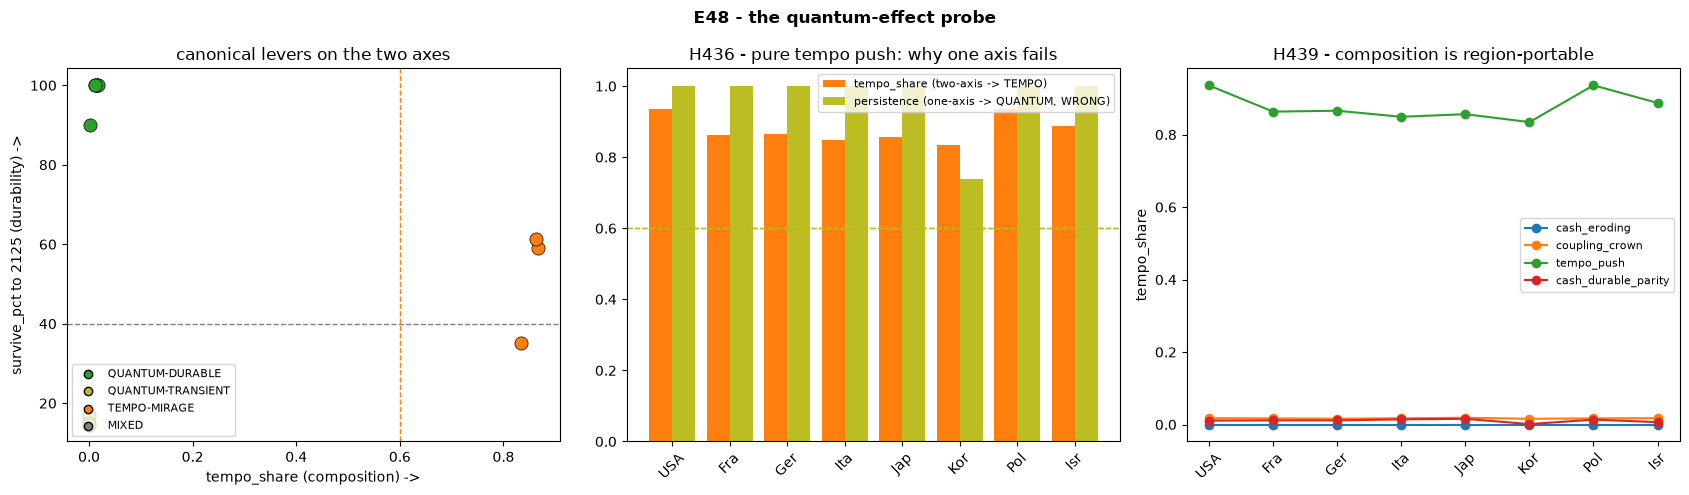

saved reports/figures/nb46_quantum_probe.png

In [15]:
fig, ax = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("E48 - the quantum-effect probe", fontweight="bold")

# (1) composition vs durability plane for the canonical levers (3 anchors)
col = {"QUANTUM-DURABLE": "tab:green", "QUANTUM-TRANSIENT": "tab:olive",
       "TEMPO-MIRAGE": "tab:orange", "MIXED": "grey", "NULL": "lightgrey"}
for reg in REGS3:
    for nm in CANON:
        r = CANON_RESULT[reg][nm]
        ax[0].scatter(r["tempo_share"], r["survive_pct"], s=90, c=col.get(r["klass"], "k"),
                      edgecolor="k", linewidth=0.5)
ax[0].axvline(TEMPO_HI, ls="--", c="tab:orange", lw=1)
ax[0].axhline(40, ls="--", c="grey", lw=1)
ax[0].set_xlabel("tempo_share (composition) ->")
ax[0].set_ylabel("survive_pct to 2125 (durability) ->")
ax[0].set_title("canonical levers on the two axes")
for k, c in col.items():
    if k != "NULL":
        ax[0].scatter([], [], c=c, edgecolor="k", label=k)
ax[0].legend(fontsize=8, loc="lower left")

# (2) H436 one-axis vs two-axis on the tempo push
regs = list(H436)
ts = [H436[r]["tempo_share"] for r in regs]
pe = [H436[r]["persistence"] for r in regs]
x = np.arange(len(regs))
ax[1].bar(x - 0.2, ts, 0.4, label="tempo_share (two-axis -> TEMPO)", color="tab:orange")
ax[1].bar(x + 0.2, pe, 0.4, label="persistence (one-axis -> QUANTUM, WRONG)", color="tab:olive")
ax[1].axhline(TEMPO_HI, ls="--", c="tab:orange", lw=1)
ax[1].axhline(PERS_HI, ls="--", c="tab:olive", lw=1)
ax[1].set_xticks(x)
ax[1].set_xticklabels([r[:3] for r in regs], rotation=45)
ax[1].set_title("H436 - pure tempo push: why one axis fails")
ax[1].legend(fontsize=8)

# (3) H439 tempo_share portability across regions
for nm in CANON:
    y = [CANON_RESULT[reg][nm]["tempo_share"] for reg in REGIONS]
    ax[2].plot(range(len(REGIONS)), y, marker="o", label=nm.split(" (")[0])
ax[2].set_xticks(range(len(REGIONS)))
ax[2].set_xticklabels([r[:3] for r in REGIONS], rotation=45)
ax[2].set_ylabel("tempo_share")
ax[2].set_title("H439 - composition is region-portable")
ax[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGS / "nb46_quantum_probe.png", dpi=110, bbox_inches="tight")
plt.show()
rprint("[green]saved[/green] reports/figures/nb46_quantum_probe.png")

## Conclusions

**What the probe is.** It is a diagnostic instrument that operationalizes the model's own Bongaarts-Feeney
quantum-vs-tempo split. Reading the model's decomposition (`adjTFR`\* for the durable completed-fertility
part, the tempo factor for the borrowed-timing part), it returns a class and a policy triple for any
intervention. Because it reads the SAME decomposition the campaign's dynamical verdicts came from, its
agreement with those verdicts REPRODUCES the model's own classifications by construction - it is an
internal-consistency check, not an independent validation and not a discovered safety property.

**Where the composition axis actually earns its keep.** In aggregate a fair one-axis persistence-only
classifier reproduces the coarse catalogue labels about as well as the two-axis probe, so aggregate
agreement (H435) does not justify the second axis. The composition axis earns its keep specifically on the
pure tempo push (H436): persistence alone reads high - lowering the mean age raises fecundability durably -
so a durability-only rule calls the mirage QUANTUM, while the composition axis reads the high tempo_share and
correctly tags TEMPO. That is one mechanism demonstrated across eight correlated regions, and it is the
round's genuinely falsifiable core.

**The measured durability split.** Composition-quantum for cash is by construction (cash writes the quantum
channel, never the tempo channel), so it is not evidence. The measured content is that an eroding cash
transfer reverts on withdrawal (survive $<$ 40) while a durable transfer held constant still persists
(survive $>$ 60) - a dynamical outcome the model could have overturned. "Borrowed timing" and "withdrawn
funding" are two things the single word "mirage" conflated.

**Portability is mostly a construction artifact.** For levers that never touch the tempo channel, tempo_share
is ~0 in every region by construction, so their "portability" is not a finding. Only variation-capable levers
(the tempo push and an added mixed cash+tempo lever) test the claim; they are portable but marginal, and only
two exist here. survive_pct still spreads with basin - the intended position signal. The classification is
robust to the one calibrated tempo constant (no class flips across kBF in {0.6, 1.0}, H440).

**Where it fails (honest-negative).** The probe answers quantum-vs-tempo, not sign: backfire and migration
levers are out of scope, NULL-effect mappings carry no verdict, and MIXED cells are abstentions, not
agreement. It reads the model's realized `dtau`, not a re-estimated `r_p` from noisy data, so it inherits the
model's tempo term rather than testing it. The thresholds (0.40 / 0.60) are pre-registered and defensible but
not derived; the wide MIXED band deliberately abstains on borderline levers rather than force-labelling
them.